Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
df = pd.read_csv("../datasets/raw/IndianWeatherRepository.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


Select Major Climate Features

In [ ]:
multivariate_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10",
]

df[multivariate_features].head()

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,visibility_km,uv_index,air_quality_PM2.5,air_quality_PM10
0,27.5,67,1008,20.5,0.0,26,10.0,7,12.6,18.5
1,27.5,70,1008,15.5,0.0,19,10.0,7,10.7,14.2
2,26.3,70,1009,18.4,0.0,51,10.0,7,16.8,20.7
3,25.6,76,1009,16.9,0.0,65,10.0,6,4.9,6.6
4,27.2,74,1009,16.2,0.0,82,10.0,6,11.4,14.8


Pairplot (Core Climate Variables)

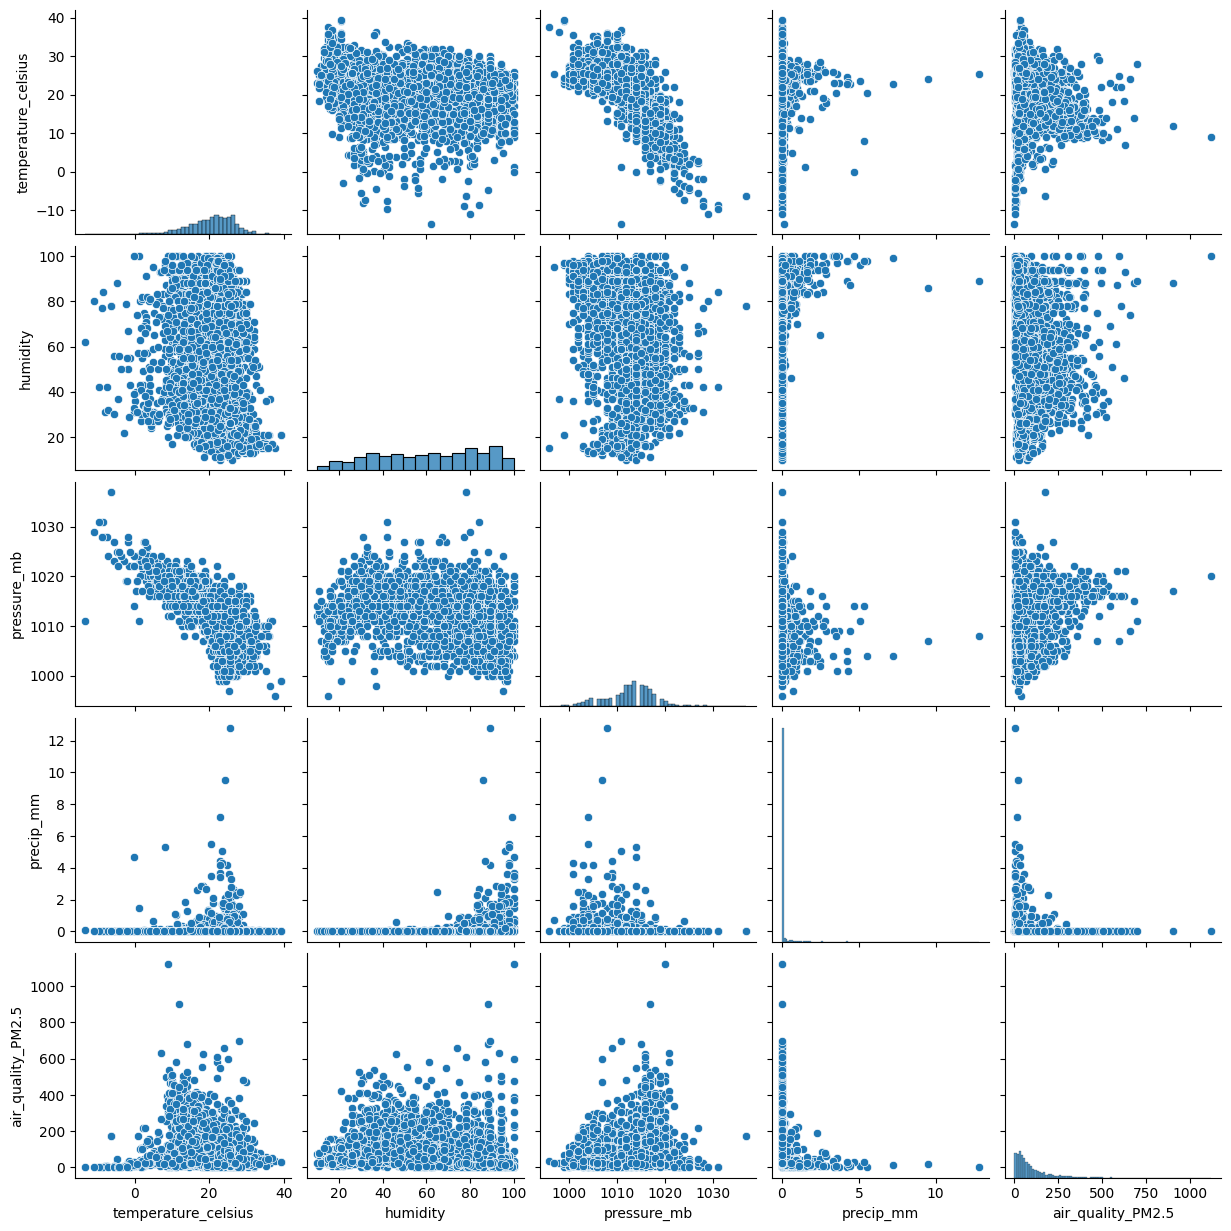

In [3]:
pairplot_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "precip_mm",
    "air_quality_PM2.5",
]

sns.pairplot(df[pairplot_features].sample(3000, random_state=42))

plt.show()

In [4]:
print("""
Pairplot reveals relationships
among major climate variables.

Useful for:
- Clustering
- Feature Engineering
- Model Development
""")


Pairplot reveals relationships
among major climate variables.

Useful for:
- Clustering
- Feature Engineering
- Model Development



Pollution Interaction Analysis

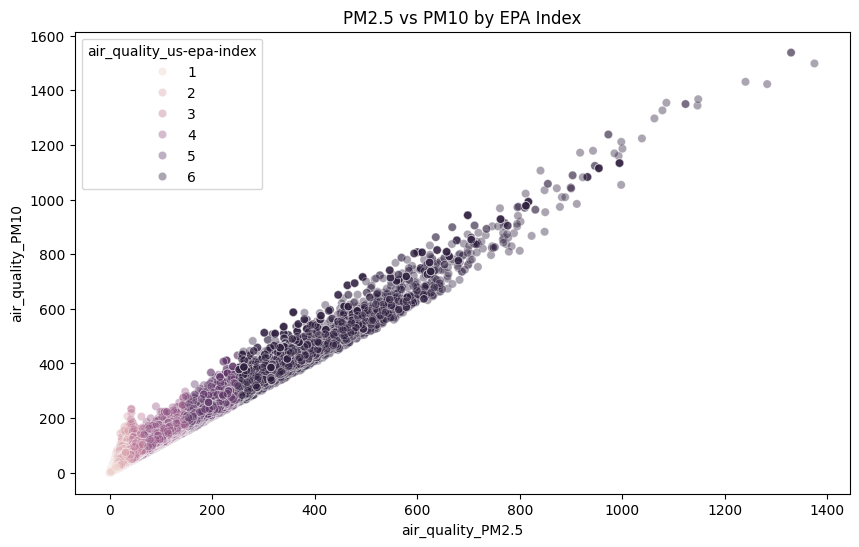

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="air_quality_PM2.5",
    y="air_quality_PM10",
    hue="air_quality_us-epa-index",
    alpha=0.4,
)

plt.title("PM2.5 vs PM10 by EPA Index")

plt.show()

In [7]:
print("""
Pollution indicators move together.
High EPA index observations
represent severe pollution events.
Useful for anomaly detection.
""")



Pollution indicators move together.
High EPA index observations
represent severe pollution events.
Useful for anomaly detection.



Weather + Pollution Interaction

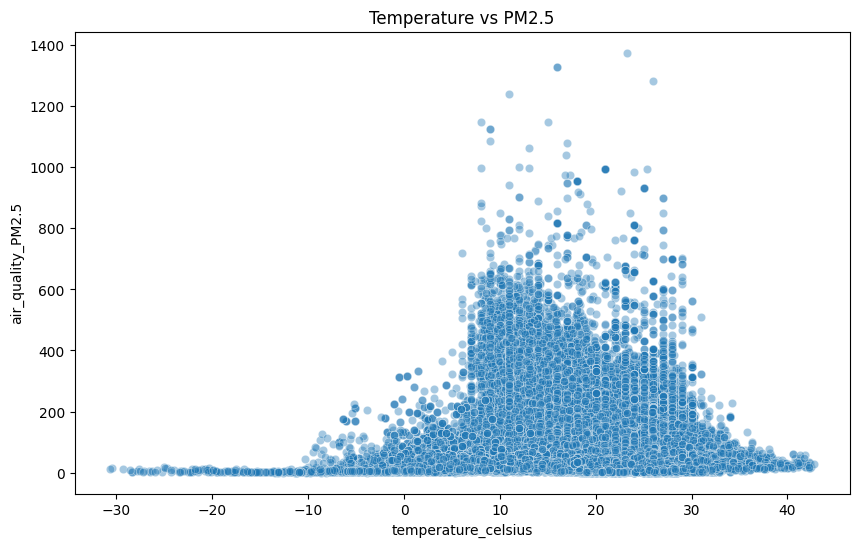

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="temperature_celsius",
    y="air_quality_PM2.5",
    alpha=0.4
)
plt.title("Temperature vs PM2.5")
plt.show()


Rainfall Predictor Combination

c:\Projects\ClimateGuardAI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


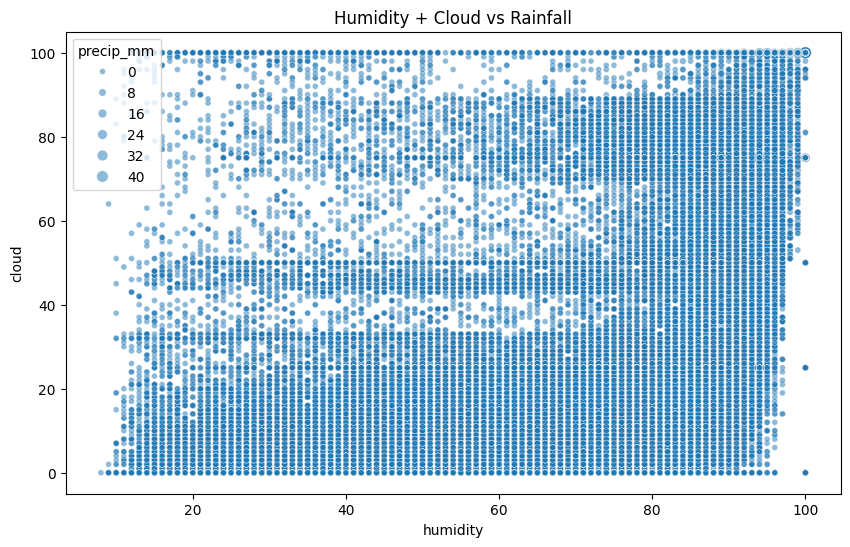

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="humidity",
    y="cloud",
    size="precip_mm",
    alpha=0.5
)
plt.title("Humidity + Cloud vs Rainfall")
plt.show()


In [10]:
print("""
Rainfall tends to occur when:
- Humidity increases
- Cloud cover increases
Strong candidate predictors
for rainfall risk modeling.
""")


Rainfall tends to occur when:
- Humidity increases
- Cloud cover increases
Strong candidate predictors
for rainfall risk modeling.



Heatwave Predictor Combination

c:\Projects\ClimateGuardAI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


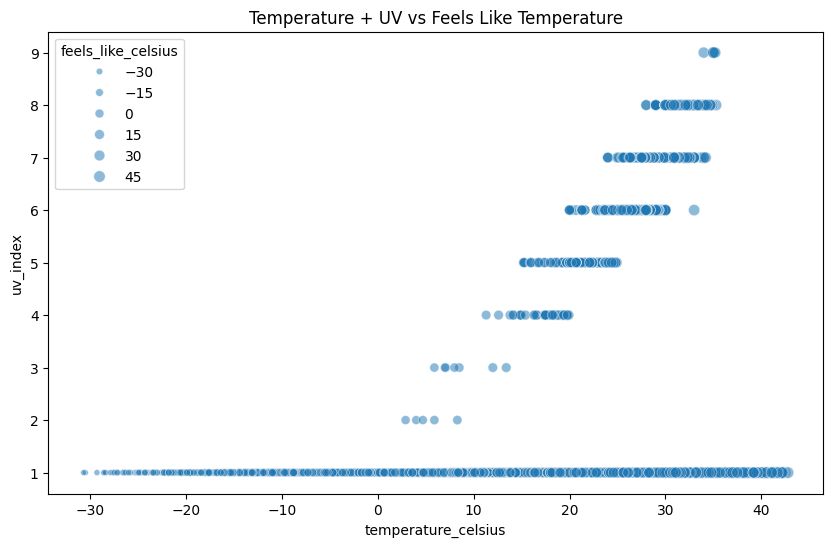

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, x="temperature_celsius", y="uv_index", size="feels_like_celsius", alpha=0.5
)
plt.title("Temperature + UV vs Feels Like Temperature")
plt.show()

In [12]:
print("""
Heatwave conditions are associated with:
- High temperature
- High UV index
- High feels-like temperature
Important for heatwave prediction.
""")


Heatwave conditions are associated with:
- High temperature
- High UV index
- High feels-like temperature
Important for heatwave prediction.



Climate Profile Candidate Features

In [13]:
cluster_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "precip_mm",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "air_quality_PM10",
]

df[cluster_features].describe()

,temperature_celsius,humidity,pressure_mb,precip_mm,visibility_km,uv_index,air_quality_PM2.5,air_quality_PM10
count,119398.000000,119398.000000,119398.000000,119398.000000,119398.000000,119398.000000,119398.000000,119398.000000
mean,20.303723,61.582681,1012.828196,0.084331,8.625313,1.084742,92.161884,109.530122
std,6.538599,23.619385,4.926352,0.608602,2.794805,0.704080,96.278193,108.621703
min,-30.700000,8.000000,991.000000,0.000000,0.000000,1.000000,0.500000,0.500000
25%,16.600000,42.000000,1010.000000,0.000000,10.000000,1.000000,30.400000,41.200000
50%,21.200000,63.000000,1013.000000,0.000000,10.000000,1.000000,60.600000,75.600000
75%,24.900000,83.000000,1016.000000,0.000000,10.000000,1.000000,117.600000,138.500000
max,42.800000,100.000000,1073.000000,43.800000,10.000000,9.000000,1374.800000,1537.800000


Anomaly Detection Candidate Features

In [14]:
anomaly_features = [
    "temperature_celsius",
    "precip_mm",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
]
df[anomaly_features].describe()

,temperature_celsius,precip_mm,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide
count,119398.000000,119398.000000,119398.000000,119398.000000,119398.000000
mean,20.303723,0.084331,92.161884,109.530122,773.096727
std,6.538599,0.608602,96.278193,108.621703,654.566069
min,-30.700000,0.000000,0.500000,0.500000,113.500000
25%,16.600000,0.000000,30.400000,41.200000,413.900000
50%,21.200000,0.000000,60.600000,75.600000,580.800000
75%,24.900000,0.000000,117.600000,138.500000,921.300000
max,42.800000,43.800000,1374.800000,1537.800000,13565.100000


In [15]:
print("""
Extreme values exist in:
- Temperature
- Rainfall
- PM2.5
- PM10
- Carbon Monoxide
These variables are strong
candidates for Isolation Forest.
""")


Extreme values exist in:
- Temperature
- Rainfall
- PM2.5
- PM10
- Carbon Monoxide
These variables are strong
candidates for Isolation Forest.



Rainfall Model Candidate Features

In [16]:
rainfall_features = [
    "humidity",
    "cloud",
    "pressure_mb",
    "wind_kph",
    "temperature_celsius",
    "precip_mm",
]
df[rainfall_features].corr()

,humidity,cloud,pressure_mb,wind_kph,temperature_celsius,precip_mm
humidity,1.000000,0.504358,-0.245403,-0.117020,0.031131,0.174144
cloud,0.504358,1.000000,-0.320283,0.053377,0.142739,0.267060
pressure_mb,-0.245403,-0.320283,1.000000,-0.204831,-0.726573,-0.157727
wind_kph,-0.117020,0.053377,-0.204831,1.000000,0.275325,0.052153
temperature_celsius,0.031131,0.142739,-0.726573,0.275325,1.000000,0.054153
precip_mm,0.174144,0.267060,-0.157727,0.052153,0.054153,1.000000


Heatwave Model Candidate Features

In [17]:
heatwave_features = [
    "temperature_celsius",
    "feels_like_celsius",
    "humidity",
    "uv_index",
    "cloud",
]

df[heatwave_features].corr()

,temperature_celsius,feels_like_celsius,humidity,uv_index,cloud
temperature_celsius,1.000000,0.983053,0.031131,0.148815,0.142739
feels_like_celsius,0.983053,1.000000,0.134282,0.168632,0.200925
humidity,0.031131,0.134282,1.000000,0.039691,0.504358
uv_index,0.148815,0.168632,0.039691,1.000000,0.056437
cloud,0.142739,0.200925,0.504358,0.056437,1.000000


Multivariate Climate Insights Report

In [18]:
print("""
MULTIVARIATE ANALYSIS REPORT
1. Climate variables interact strongly.
2. Temperature, humidity and pressure
show climate dependencies.
3. PM2.5 and PM10 move together.
4. Rainfall is associated with:
   - Humidity
   - Cloud Cover
   - Pressure
5. Heatwave conditions are associated with:
   - Temperature
   - Feels Like Temperature
   - UV Index
6. Pollution indicators are useful for:
   - Climate Profiling
   - Anomaly Detection
7. Candidate features identified for:

   - KMeans Clustering
   - Isolation Forest
   - Rainfall Prediction
   - Heatwave Prediction
8. Dataset is ready for:
   - Correlation Analysis (C5)
""")


MULTIVARIATE ANALYSIS REPORT
1. Climate variables interact strongly.
2. Temperature, humidity and pressure
show climate dependencies.
3. PM2.5 and PM10 move together.
4. Rainfall is associated with:
   - Humidity
   - Cloud Cover
   - Pressure
5. Heatwave conditions are associated with:
   - Temperature
   - Feels Like Temperature
   - UV Index
6. Pollution indicators are useful for:
   - Climate Profiling
   - Anomaly Detection
7. Candidate features identified for:

   - KMeans Clustering
   - Isolation Forest
   - Rainfall Prediction
   - Heatwave Prediction
8. Dataset is ready for:
   - Correlation Analysis (C5)

